In [ ]:
# https://ai.google.dev/edge/mediapipe/solutions/guide?hl=ko

Text(0.5, 1.0, 'RGB image')

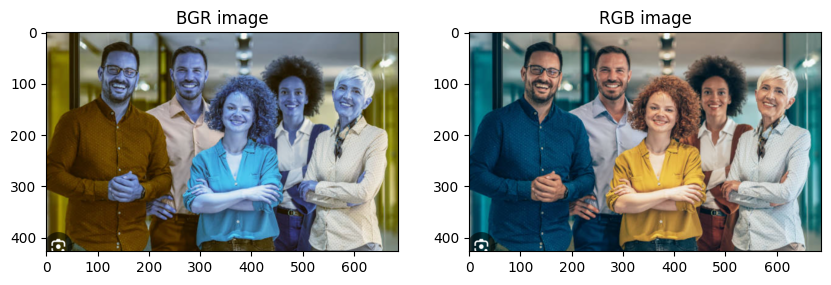

In [8]:
##################################################
## (사전지식)
## openCV는 이미지를 읽으면서 자동으로 숫자(넘파이)로 변환함
## open CV는 이미지를 읽을때 BGR로 읽기 때문에
## openCV의 전문 출력장치에서는 문제가 되지 않으나
## plt.imshow 로 출력할때는 rgb로 출력하지 않으면 색상값이 이상하게 나옴
## cv2.imshow("Image with Green Box", image) 로 하면 알아서 bgr이 rgb로 나옴
##########################################################

import cv2
import matplotlib.pyplot as plt
img_files=['c:/data/img2.png']
file=img_files[0]
image=cv2.imread(file)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(image)
plt.title('BGR image')

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(image,cv2.COLOR_BGR2RGB))
plt.title('RGB image')

In [ ]:
# 미디어파이프 모듈
!pip show mediapipe

Name: mediapipe
Version: 0.10.11
Summary: MediaPipe is the simplest way for researchers and developers to build world-class ML solutions and applications for mobile, edge, cloud and the web.
Home-page: https://github.com/google/mediapipe
Author: The MediaPipe Authors
Author-email: mediapipe@google.com
License: Apache 2.0
Location: c:\users\admin\miniconda3\envs\kpmg\lib\site-packages
Requires: absl-py, attrs, flatbuffers, jax, matplotlib, numpy, opencv-contrib-python, protobuf, sounddevice
Required-by: 


In [ ]:
####################################
## C:\Users\Admin\miniconda3\envs\kpmg\Lib\site-packages\mediapipe\python\solutions\face_detection.py
##
## 얼굴의 눈2, 코, 입2, 귀2 위치값 검출
##   RIGHT_EYE = 0
##  LEFT_EYE = 1
##  NOSE_TIP = 2
##  MOUTH_CENTER = 3
##  RIGHT_EAR_TRAGION = 4
##  LEFT_EAR_TRAGION = 5
###################################
import cv2
import mediapipe as mp
import matplotlib.pyplot as plt
mp_face_detection=mp.solutions.face_detection
mp_drawing=mp.solutions.drawing_utils

img_files=['c:/data/short_img.png', 'c:/data/img2.png']
file=img_files[1]

#model_selection=1 을 생략하면 0임 / 0은2m내의 가까운 거리, 1은 5m내의 전신거리
with mp_face_detection.FaceDetection(model_selection=1) as face_detection:
    image=cv2.imread(file)
    image=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
    results=face_detection.process(image)
    print(f'검출된 얼굴수는: {len(results.detections)})')
    print(results.detections)  # 출력자료는 모두다 너비와 높이를 1값으로 변경하여서 보여줌


# 출력되는 값은 모두다 0-1값으로 변경된 값임. 즉 이미지의 너비가 200이어도 1로, 300이어도 1로 값이 변경되어서 계산됨

검출된 얼굴수는: 5)
[label_id: 0
score: 0.9555335640907288
location_data {
  format: RELATIVE_BOUNDING_BOX
  relative_bounding_box {
    xmin: 0.49701642990112305
    ymin: 0.3081711232662201
    width: 0.09186822175979614
    height: 0.14778470993041992
  }
  relative_keypoints {
    x: 0.5257226824760437
    y: 0.34959813952445984
  }
  relative_keypoints {
    x: 0.5667619705200195
    y: 0.3564446270465851
  }
  relative_keypoints {
    x: 0.5447396636009216
    y: 0.3809144198894501
  }
  relative_keypoints {
    x: 0.5427567362785339
    y: 0.4122835099697113
  }
  relative_keypoints {
    x: 0.5031290054321289
    y: 0.36698177456855774
  }
  relative_keypoints {
    x: 0.5922447443008423
    y: 0.38320305943489075
  }
}
, label_id: 0
score: 0.951390266418457
location_data {
  format: RELATIVE_BOUNDING_BOX
  relative_bounding_box {
    xmin: 0.6432108283042908
    ymin: 0.22425177693367004
    width: 0.104644775390625
    height: 0.16836512088775635
  }
  relative_keypoints {
    x: 0.

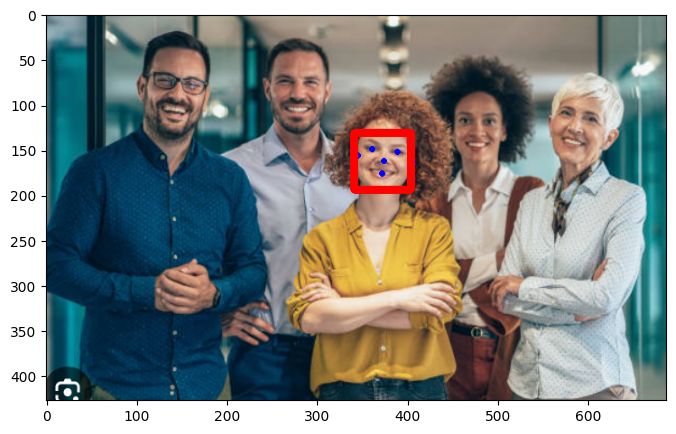

In [56]:
##############################
## 이미지 점 및 박스 그리기
###############################
mp_drawing=mp.solutions.drawing_utils
annotated_image=image.copy() # 원본보존
detection=results.detections[0]
mp_drawing.draw_detection(annotated_image,
                          detection,
                          bbox_drawing_spec=mp_drawing.DrawingSpec(color=(255,0,0), thickness=7))
plt.figure(figsize=(8,20))
plt.imshow(annotated_image)
plt.show()

In [65]:
##############################
## 이미지 key포인트값 받기
## 얼굴의 눈2, 코, 입2, 귀2 위치값 검출
##   RIGHT_EYE = 0
##  LEFT_EYE = 1
##  NOSE_TIP = 2
##  MOUTH_CENTER = 3
##  RIGHT_EAR_TRAGION = 4
##  LEFT_EAR_TRAGION = 5
###############################
print('눈의 위치는')
point=mp_face_detection.get_key_point(detection, mp_face_detection.FaceKeyPoint(0))
print(point)

print('모든 위치알기')
pointName=['RIGHT_EYE','LEFT_EYE','NOSE_TIP','MOUTH_CENTER','RIGHT_EAR_TRAGION','LEFT_EAR_TRAGION']
for x in range(6):
    point=mp_face_detection.get_key_point(detection, mp_face_detection.FaceKeyPoint(x))
    print(f'--> {pointName[x]}')
    print(point)



눈의 위치는
x: 0.5257226824760437
y: 0.34959813952445984

모든 위치알기
--> RIGHT_EYE
x: 0.5257226824760437
y: 0.34959813952445984

--> LEFT_EYE
x: 0.5667619705200195
y: 0.3564446270465851

--> NOSE_TIP
x: 0.5447396636009216
y: 0.3809144198894501

--> MOUTH_CENTER
x: 0.5427567362785339
y: 0.4122835099697113

--> RIGHT_EAR_TRAGION
x: 0.5031290054321289
y: 0.36698177456855774

--> LEFT_EAR_TRAGION
x: 0.5922447443008423
y: 0.38320305943489075



In [ ]:
######################################
## 위의 자료를 이용하여서 직접 박스를 그린다고 한다면
#######################################

In [41]:
#############################################################
## 아래와 같이 그리지 않아도 자체적으로 그려주는 draw함수가 있음
#############################################################
tmp=results.detections[0].location_data.relative_bounding_box
tmp

xmin: 0.49701642990112305
ymin: 0.3081711232662201
width: 0.09186822175979614
height: 0.14778470993041992

In [33]:
# 읽어들인 이미지의 원래크기를 이용해서 
print(image.shape)
h,w=image.shape[0], image.shape[1]
print(f'w:{w} , h;{h}')

(427, 687, 3)
w:687 , h;427


In [43]:
str(tmp)

'xmin: 0.49701642990112305\nymin: 0.3081711232662201\nwidth: 0.09186822175979614\nheight: 0.14778470993041992\n'

In [45]:
str(tmp).split('\n')

['xmin: 0.49701642990112305',
 'ymin: 0.3081711232662201',
 'width: 0.09186822175979614',
 'height: 0.14778470993041992',
 '']

In [48]:
xy=[]
for aa in str(tmp).split('\n')[:-1]:
    print(aa.split(':'))
    xy.append(float(aa.split(':')[1]))
xy

['xmin', ' 0.49701642990112305']
['ymin', ' 0.3081711232662201']
['width', ' 0.09186822175979614']
['height', ' 0.14778470993041992']


[0.49701642990112305,
 0.3081711232662201,
 0.09186822175979614,
 0.14778470993041992]

In [51]:
# 원래 이미지 크기
import numpy as  np
w = 687
h = 427

# 정규화된 값 (x 시작점, y 시작점, 너비, 높이)
normalized_values = [
    0.49701642990112305,
    0.3081711232662201,
    0.09186822175979614,
    0.14778470993041992
]

# 정규화된 값을 원래 크기로 변환
x_start = int(normalized_values[0] * w)
y_start = int(normalized_values[1] * h)
box_width = int(normalized_values[2] * w)
box_height = int(normalized_values[3] * h)

# 이미지 생성 (여기서는 빈 이미지 생성)
image =cv2.imread(file)

# 초록색 박스 그리기
top_left = (x_start, y_start)
bottom_right = (x_start + box_width, y_start + box_height)
cv2.rectangle(image, top_left, bottom_right, (0, 255, 0), 2)  # 초록색 (0, 255, 0), 두께 2

# 결과 이미지 출력
cv2.imshow("Image with Green Box", image)
cv2.waitKey(0)
cv2.destroyAllWindows()